# Source Apportionment

In the previous tutorials, we learnt to answer the following questions:

1. How much is the pollution?
2. Where is the pollution? and
3. When is the pollution?

But it is also important that we know the sources of the pollution in a city. Only by knowing sources that we can think of reducing ways to reduce pollution. We know about sources of pollution by conducting source apportionment studies.

The source apportionment studies are not easy to conduct. They require a lot of skilled personnel for monitoring, data modeling, laboratory facilities and financial support. There are a few institutions that have the wherewithal to conduct source apportionment studies. There are two ways in which source apportionment can be done:
1. **Top-down way: Using Receptor Modeling (RM)**
2. **Bottom-up way: Emissions Modeling.**

[What is Source Apportionment? A Primer by UrbanEmissions.Info](https://urbanemissions.info/wp-content/uploads/docs/Primer-What-is-Source-Apportionment-English.pdf)

## Top-down: Receptor Modeling (RM) based source apportionment

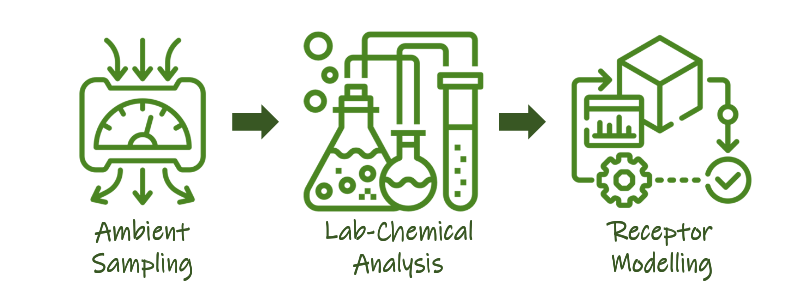

The World Health Organisation (W.H.O) collected source apportionment studies performed in various cities across the world between 1990-2014. This is a good dataset to explore source apportionment.

[Database on source apportionment studies for particulate matter - W.H.O](https://www.who.int/data/gho/data/themes/air-pollution/source-apportionment-db)

In [6]:
import pandas as pd
who_sources_db = pd.read_csv('data/database_source_apport_studies_v2_0_26_9_2015.csv')
who_sources_db.sample(5)

,Site Location,Population estimate *,Country,ISO 3 code,Country Region,continent,Latitude,Longitude,Site typology,PM10 µgm-3 *,...,Reference author,Reference year,Study year,Season,SEA SALT%,DUST%,TRAFFIC%,INDUSTRY%,BIOM. BURN./RES.%,OTHER (unspecified-human origin)%
293,Santander,"1,78,475",Spain,ESP,Southwestern Europe,EU,43.47,-3.81,urban,NaN,...,"Moreno171,172",2011.0,2007/8,year,13.0,1.0,37.0,7.0,NaN,42.0
503,Rio de Janeiro,"63,20,000",Brazil,BRA,Brazil,SA,-22.90,-43.21,urban,NaN,...,Godoy5,2009.0,2003/2005,year,NaN,36.0,29.0,35.0,NaN,0.0
439,Corpus Christi,"3,12,195",USA,USA,USA,NaN,27.42,-97.29,rural,NaN,...,Subramoney116,2013.0,2003/2005,year,15.0,4.0,26.0,NaN,3.0,52.0
270,La Linea,"64,645",Spain,ESP,Southwestern Europe,EU,36.16,-5.35,urban-industrial,NaN,...,Amato128–131,2014.0,2003/2010,year,9.0,5.0,25.0,14.0,NaN,47.0
492,Jamari(†),< 50,Brazil,BRA,Brazil,SA,-9.20,-63.17,rural,105.0,...,"Artaxo2,3",1998.0,1995,fall,5.9,21.3,NaN,NaN,54.0,18.8


`SEA SALT`, `DUST`, `TRAFFIC`, `INDUSTRY`, `BIOMASS BURNING/RESIDENTIAL` and `OTHERS` are the sources recognised in this database for each city. 

In [47]:
sources = ['SEA SALT%', 'DUST%', 'TRAFFIC%', 'INDUSTRY%', 'BIOM. BURN./RES.%',
       'OTHER (unspecified-human origin)%']

The W.H.O database is a collection of all RM source apportionment studies. We can see that there are several methods of performing an RM study.

In [48]:
who_sources_db['Methodology'].unique()

array(['PCA', 'CMB', 'PMF', 'UNMIX', 'APCS', 'FA', 'LENSCHOW', 'ME',
       'PCA-MLR', 'PCA/APCS', 'CMF', 'COPREM', 'APEG', 'PCFA', 'APCFA',
       'MC', 'PMF-ME', 'PMF-UNMIX', 'CMB/UNMIX', 'APCA', 'APFA', nan],
      dtype=object)

### Source apportionment pie

Let's learn to build a source apportionment pie for the city `Beijing` using the `2010` study. 

In [45]:
required_columns  = ['Site Location','Country','Site typology', 'PM2.5 µgm-3 *', 'Methodology', 'Season']+sources
city = 'Beijing'
year = '2010'

In [77]:
Beijing_2010_SA = who_sources_db[(who_sources_db['Site Location']==city)&(who_sources_db['Study year']==year)][required_columns]
Beijing_2010_SA

,Site Location,Country,Site typology,PM2.5 µgm-3 *,Methodology,Season,SEA SALT%,DUST%,TRAFFIC%,INDUSTRY%,BIOM. BURN./RES.%,OTHER (unspecified-human origin)%
98,Beijing,China,urban,55,PMF,year,NaN,10.4,29.7,22.0,11.2,26.7


From this source apportionment study, we can infer the following details:

1. The annual PM2.5 concentration in Beijing in 2010 was 55 µg/m3.
2. The source apportionment study was performed by the `PMF` method (Positive Matrix Factorization). It is a Receptor Modeling (RM) method. You can read more about it here: [Positive Matrix Factorization Model for Environmental Data Analyses | US EPA](https://www.epa.gov/air-research/positive-matrix-factorization-model-environmental-data-analyses)
3. `TRAFFIC` is the major source of PM2.5 followed by`INDUSTRY`, `BIOMASS BURNING/RESIDENTIAL` and `DUST`.

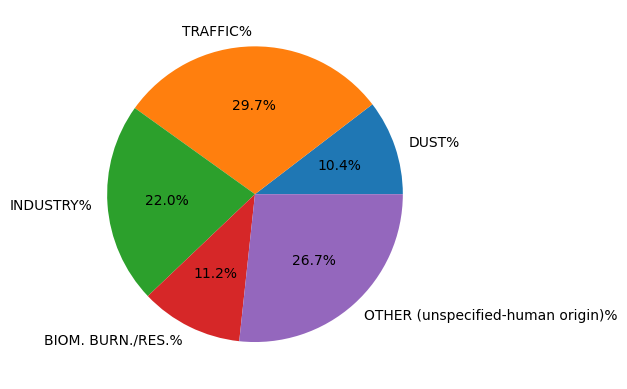

In [91]:
import matplotlib.pyplot as plt
source_contributions = list(Beijing_2010_SA[sources].dropna(axis=1).values.flatten())
sources = Beijing_2010_SA[sources].dropna(axis=1).columns

fig, ax = plt.subplots()
ax.pie(source_contributions,
       labels=sources,
       autopct='%1.1f%%')
plt.show()

We can also calculate the contributions of each source to PM2.5 in µg/m3 by multiplying the total PM2.5 concentration with source percentage.

In [106]:
pm25 = float(Beijing_2010_SA['PM2.5 µgm-3 *'].values[0])

print(f"Beijing's annual PM2.5 concentration in 2010 is {pm25} µg/m3 \n Of which, the contribution of:")
for source, contribution in zip(sources,source_contributions):
    print(f"{source[:-1]} is {round(contribution*pm25/100,2)} µg/m3")

Beijing's annual PM2.5 concentration in 2010 is 55.0 µg/m3 
 Of which, the contribution of:
DUST is 5.72 µg/m3
TRAFFIC is 16.34 µg/m3
INDUSTRY is 12.1 µg/m3
BIOM. BURN./RES. is 6.16 µg/m3
OTHER (unspecified-human origin) is 14.68 µg/m3


We know that `W.H.O annual standard of PM2.5 is 5 µg/m3`. Thus, the least contributive source `DUST` alone was responsible in Beijing to cross the W.H.O standard. This gives us some insight on where to focus in reducing pollution.

## Bottom-up: Emissions based Source Apportionment

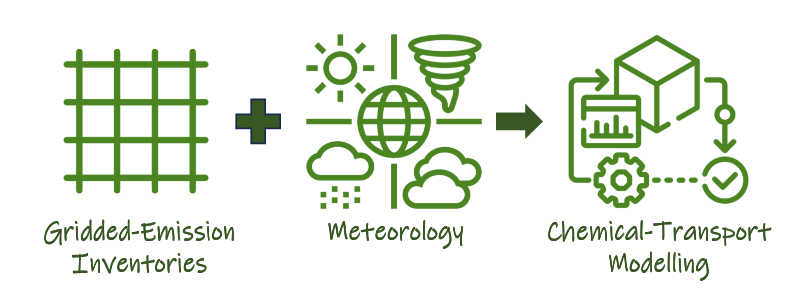

Another way to estimate source contributions is from sector specific emissions in a city. The advantage of using Emissions based approach is that we can forecast emissions of a city and thus forecast future sources of air pollution.

UrbanEmissions.Info performed emissions based PM2.5 source apportionment studies for various cities in India as part of the [Air Pollution
Knowledge Assessment (APnA) City Program](https://urbanemissions.info/india-apna/). You can see the source apportionment pies of these cities, here: [Link](https://urbanemissionsinfo.github.io/source_apportionment/index.html)

In [17]:
apna = pd.read_csv('data/APnA_50airsheds_PM25_Source_Apportionment_CAMxOutputs.csv')
apna.tail()

,Airshed,City,Transport,Residential,Industrial,Dust,Waste,Diesel Genset,Brick Kiln,Sea Salt,External,study_year
44,45,Nagpur,17.20%,6.80%,26.70%,10.90%,11.60%,1.80%,3.20%,NaN,21.40%,2017
45,46,Patna,14.80%,14.60%,11.20%,12.10%,12.90%,5.40%,9.30%,NaN,19.20%,2017
46,47,Pune-Pimpri-Chinchwad,24.00%,5.80%,9.80%,23.40%,6.40%,2.80%,2.60%,NaN,24.70%,2017
47,48,Raipur-Durg-Bhillai,17.20%,11.80%,22.80%,11.50%,6.20%,2.80%,1.40%,NaN,25.80%,2017
48,49,Ranchi,21.10%,18.00%,1.10%,14.10%,12.20%,1.30%,3.20%,NaN,28.50%,2017


We can note that this study identified more sources than the previous one: `Transport`, `Residential`, `Dust`, `Waste`, `Diesel Genset`, `Brick Kiln`, `Sea Salt` and `External`. 

In [18]:
sources =  ['Transport', 'Residential', 'Industrial', 'Dust', 'Waste', 'Diesel Genset', 'Brick Kiln', 'Sea Salt', 'External']

### Scenario building

When we have source apportionment data, we can also build various scenarios of air pollution. We will build a scenario for the city of Mumbai. You can download the APnA leaflet for Mumbai from here: [Mumbai APnA 2019](https://urbanemissions.info/wp-content/uploads/apna/docs/india_apna_2019_mumbai.pdf). 

In 2018, the annual average PM2.5 concentration in Mumbai was 51.5 µg/m3. We can obtain source contributions from the APnA dataset.

In [76]:
pm25_mumbai = 51.5 #µg/m3
mumbai_sources = apna[apna.City =='Mumbai']
mumbai_sources

,Airshed,City,Transport,Residential,Industrial,Dust,Waste,Diesel Genset,Brick Kiln,Sea Salt,External,study_year
17,18,Mumbai,16.40%,3.20%,15.00%,12.60%,3.80%,1.90%,2.30%,12.10%,32.60%,2019


In [ ]:
# Percentage reduction in each source
reductions={'Transport':30,'Residential':40, 'Industrial':35, 'Dust':50, 'Waste':60, 'Diesel Genset':50,
            'Brick Kiln':80, 'Sea Salt':0, 'External':0}

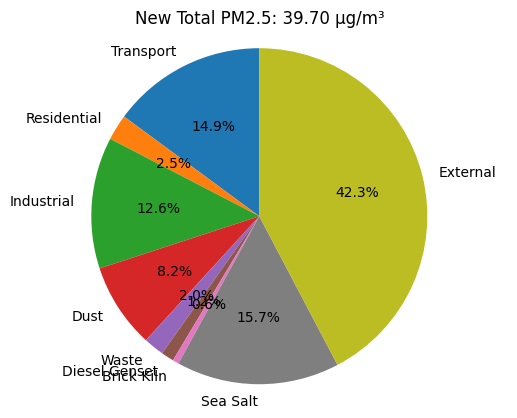

Original: 51.45 µg/m³
New: 39.70 µg/m³
Reduction: 11.75 µg/m³


In [88]:
#| code-fold: true
#| code-summary: "Show hidden code that builds the scenario player"

import ipywidgets as widgets
from IPython.display import display

# Source contributions in #µg/m3
base_contrib = mumbai_sources[sources].T
base_contrib.columns = ['source_contribution']
base_contrib = base_contrib.source_contribution.str[:-1].astype(float)*pm25_mumbai/100
pm25_mumbai_ = round(base_contrib.sum(),2)


sliders = {}

for col in sources:
    sliders[col] = widgets.FloatSlider(
        value=reductions[col], min=0, max=100, step=1,
        description=col,
        continuous_update=False
    )

def update(**reductions):
    new_contrib = base_contrib.copy()
    
    for source, reduction in reductions.items():
        new_contrib[source] *= (1 - reduction/100)

    new_total = round(new_contrib.sum(),2)
    
    # ---- PIE CHART ----
    plt.figure()
    
    # # optional: remove very small slices for clarity
    # plot_data = new_contrib[new_contrib > 2]
    
    plt.pie(
        new_contrib,
        labels=new_contrib.index,
        autopct='%1.1f%%',
        startangle=90
    )
    
    plt.title(f"New Total PM2.5: {new_total:.2f} µg/m³")
    plt.axis('equal')  # keeps it circular
    
    plt.show()
    
    print(f"Original: {pm25_mumbai_:.2f} µg/m³")
    print(f"New: {new_total:.2f} µg/m³")
    print(f"Reduction: {pm25_mumbai_ - new_total} µg/m³")
    
update(**{k:reductions[k] for k in sliders})

In [89]:
#| code-fold: true
#| code-summary: "Show hidden code to run scenario player in Colab/Jupyter"
ui = widgets.VBox(list(sliders.values()))
out = widgets.interactive_output(update, sliders)
title = widgets.HTML("<h3>Adjust Source Reductions (%)</h3>")
display(title, ui, out)

HTML(value='<h3>Adjust Source Reductions (%)</h3>')

Output(outputs=({'output_type': 'display_data', 'data': {'text/plain': '<Figure size 640x480 with 1 Axes>', 'i…

We can thus play with various scenarios and see when the city of `Mumbai` can meet the Air Quality Standards. The above is one such scenario when we can observe that Mumbai's PM2.5 annual average met NAAQS of 40µg/m³. Ofcourse, if the specified reductions are practical or not is another debate. But with these scenario players we can start thinking about solutions to the air pollution problem

## Summary

In this tutorial, we learnt what is source apportionment and various methods of performing source apportionment studies. We explored the  database on source apportionment studies and worked with Beijing's data to create a source apportionment pie. We then built a scenario player using Mumbai's emission based source apportionment study and saw how Mumbai can reach NAAQS standard of 40 µg/m³.